In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
SEED = 42
np.random.seed(SEED)

LOGS = Path('../../logs/paper_trading')
START_CAPITAL = 1000.0

print('Phase 6 Analysis loaded')

Phase 6 Analysis loaded


In [2]:
def load_checkpoint(path):
    """Load checkpoint.json → trades, positions, cash."""
    with open(path) as f:
        d = json.load(f)
    trades = pd.DataFrame(d.get('trades', []))
    positions = d.get('positions', {})
    cash = d.get('cash', START_CAPITAL)
    return trades, positions, cash

def load_equity(directory):
    """Load latest equity CSV from directory."""
    csvs = sorted(directory.glob('paper_equity_*.csv'))
    if not csvs:
        return None
    df = pd.read_csv(csvs[-1])
    df['time'] = pd.to_datetime(df['time'])
    return df

instances = {}
configs = {
    'main': {'cp': LOGS / 'checkpoint.json', 'eq_dir': LOGS},
    'v1_baseline': {'cp': LOGS / 'v1_baseline' / 'checkpoint.json', 'eq_dir': LOGS / 'v1_baseline'},
    'v2': {'cp': LOGS / 'v2' / 'checkpoint.json', 'eq_dir': LOGS / 'v2'},
    'small_markets': {'cp': LOGS / 'small_markets' / 'checkpoint.json', 'eq_dir': LOGS / 'small_markets'},
    'small_longshot': {'cp': LOGS / 'small_longshot' / 'checkpoint.json', 'eq_dir': LOGS / 'small_longshot'},
}

archive = LOGS / 'archive'
if archive.exists():
    for d in sorted(archive.iterdir()):
        cp = d / 'checkpoint.json'
        if cp.exists():
            name = d.name.rsplit('_', 2)[0]
            configs[name] = {'cp': cp, 'eq_dir': d}

for name, cfg in configs.items():
    try:
        trades, positions, cash = load_checkpoint(cfg['cp'])
        equity = load_equity(cfg['eq_dir'])
        instances[name] = {
            'trades': trades, 'positions': positions,
            'cash': cash, 'equity': equity,
        }
        n_trades = len(trades)
        pnl = trades['pnl'].sum() if n_trades > 0 else 0
        wr = (trades['pnl'] > 0).mean() * 100 if n_trades > 0 else 0
        print(f'{name:20s}: {n_trades:3d} trades, PnL ${pnl:+.2f}, WR {wr:.0f}%, '
              f'{len(positions)} open, cash ${cash:.0f}')
    except Exception as e:
        print(f'{name:20s}: FAILED — {e}')

main_trades = instances['main']['trades'].copy()
main_equity = instances['main']['equity'].copy()
print(f'\nMain: {len(main_trades)} trades, equity CSV {len(main_equity)} rows')

main                : 248 trades, PnL $-25.88, WR 47%, 2 open, cash $762
v1_baseline         :  20 trades, PnL $-43.73, WR 45%, 0 open, cash $956
v2                  :  20 trades, PnL $-40.17, WR 30%, 0 open, cash $960
small_markets       :  13 trades, PnL $-29.87, WR 23%, 0 open, cash $970
small_longshot      :  15 trades, PnL $-51.07, WR 7%, 0 open, cash $949
inverse             :  16 trades, PnL $-74.81, WR 12%, 0 open, cash $925
sports_only         :  18 trades, PnL $-74.96, WR 6%, 0 open, cash $925

Main: 248 trades, equity CSV 10949 rows


In [3]:
rows = []
for name, data in instances.items():
    t = data['trades']
    if len(t) == 0:
        continue
    pnl = t['pnl'].sum()
    wins = (t['pnl'] > 0).sum()
    losses = (t['pnl'] <= 0).sum()
    wr = wins / len(t) * 100
    avg_win = t.loc[t['pnl'] > 0, 'pnl'].mean() if wins > 0 else 0
    avg_loss = t.loc[t['pnl'] <= 0, 'pnl'].mean() if losses > 0 else 0
    pf = abs(t.loc[t['pnl'] > 0, 'pnl'].sum() / t.loc[t['pnl'] <= 0, 'pnl'].sum()) if losses > 0 else np.inf

    eq = data.get('equity')
    if eq is not None and len(eq) > 0:
        eqv = eq['mtm_equity'].values
        peak = np.maximum.accumulate(eqv)
        dd = np.where(peak > 0, (eqv - peak) / peak * 100, 0)
        max_dd = dd.min()
    else:
        max_dd = 0
    rows.append({
        'Instance': name, 'Trades': len(t), 'Wins': wins, 'Losses': losses,
        'WR %': f'{wr:.1f}', 'PnL $': f'{pnl:+.2f}',
        'Avg Win $': f'{avg_win:.2f}', 'Avg Loss $': f'{avg_loss:.2f}',
        'PF': f'{pf:.2f}' if pf < 100 else 'inf',
        'Max DD %': f'{max_dd:.1f}',
        'Open': len(data['positions']),
    })

summary = pd.DataFrame(rows).set_index('Instance')
summary

,Trades,Wins,Losses,WR %,PnL $,Avg Win $,Avg Loss $,PF,Max DD %,Open
Instance,,,,,,,,,,
main,248,116,132,46.8,-25.88,5.24,-4.80,0.96,-12.1,2
v1_baseline,20,9,11,45.0,-43.73,2.56,-6.07,0.35,-5.5,0
v2,20,6,14,30.0,-40.17,2.23,-3.82,0.25,-4.8,0
small_markets,13,3,10,23.1,-29.87,5.18,-4.54,0.34,-5.0,0
small_longshot,15,1,14,6.7,-51.07,0.39,-3.68,0.01,-5.0,0
inverse,16,2,14,12.5,-74.81,1.76,-5.59,0.04,-7.2,0
sports_only,18,1,17,5.6,-74.96,0.35,-4.43,0.00,-7.2,0


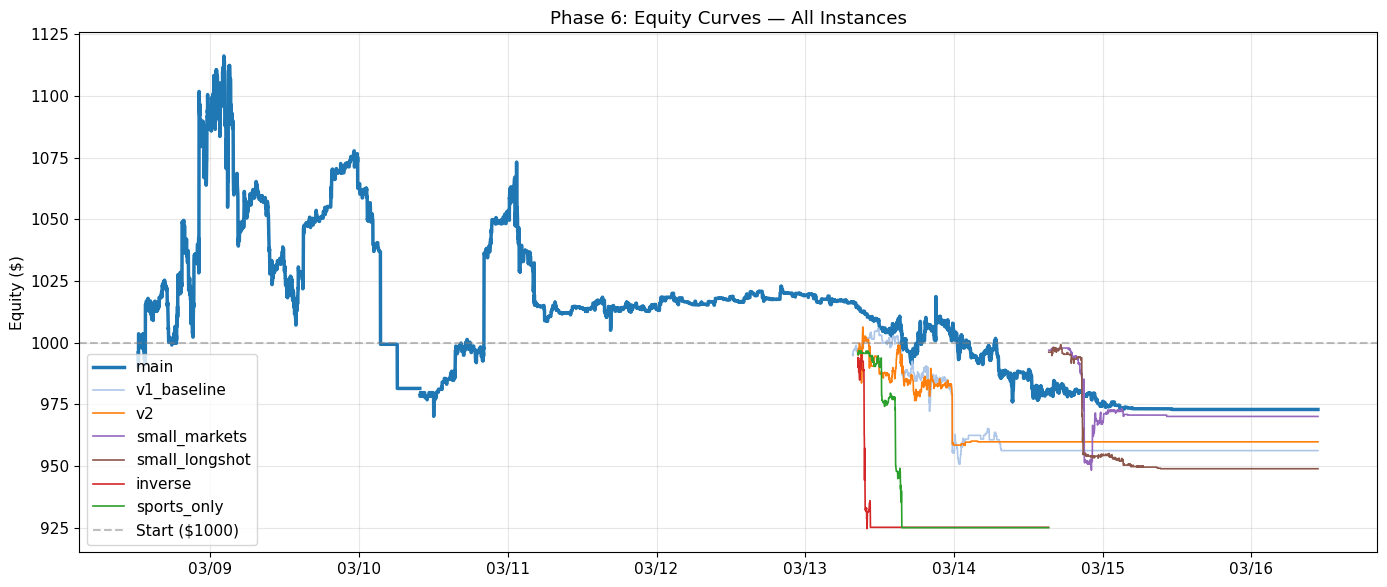

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = {'main': '#1f77b4', 'v1_baseline': '#aec7e8', 'v2': '#ff7f0e',
          'small_markets': '#9467bd', 'small_longshot': '#8c564b',
          'sports_only': '#2ca02c', 'inverse': '#d62728'}

for name, data in instances.items():
    eq = data.get('equity')
    if eq is not None and len(eq) > 10:
        ax.plot(eq['time'], eq['mtm_equity'], label=name,
                color=colors.get(name, 'gray'),
                linewidth=2.5 if name == 'main' else 1.2)

ax.axhline(y=START_CAPITAL, color='gray', linestyle='--', alpha=0.5, label='Start ($1000)')
ax.set_title('Phase 6: Equity Curves — All Instances')
ax.set_ylabel('Equity ($)')
ax.legend(loc='lower left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
for col in ['entry_time', 'exit_time']:
    if col in main_trades.columns:
        main_trades[col] = pd.to_datetime(main_trades[col])

if 'entry_time' in main_trades.columns and 'exit_time' in main_trades.columns:
    main_trades['hold_hours'] = (main_trades['exit_time'] - main_trades['entry_time']).dt.total_seconds() / 3600

if 'exit_time' in main_trades.columns:
    main_trades['exit_date'] = main_trades['exit_time'].dt.date

pnls = main_trades['pnl'].values
print(f'=== PnL Distribution (Main, N={len(pnls)}) ===')
print(f'Mean:   ${np.mean(pnls):+.2f}')
print(f'Median: ${np.median(pnls):+.2f}')
print(f'Stdev:  ${np.std(pnls):.2f}')
print(f'Skew:   {pd.Series(pnls).skew():.3f}')
print(f'Kurt:   {pd.Series(pnls).kurtosis():.3f}')
print(f'Min:    ${pnls.min():+.2f}')
print(f'Max:    ${pnls.max():+.2f}')
print(f'\nPercentiles:')
for q in [5, 25, 50, 75, 95]:
    print(f'  P{q}: ${np.percentile(pnls, q):+.2f}')

=== PnL Distribution (Main, N=248) ===
Mean:   $-0.10
Median: $-0.13
Stdev:  $9.44
Skew:   1.405
Kurt:   14.024
Min:    $-38.15
Max:    $+67.51

Percentiles:
  P5: $-16.91
  P25: $-1.58
  P50: $-0.13
  P75: $+1.38
  P95: $+10.55


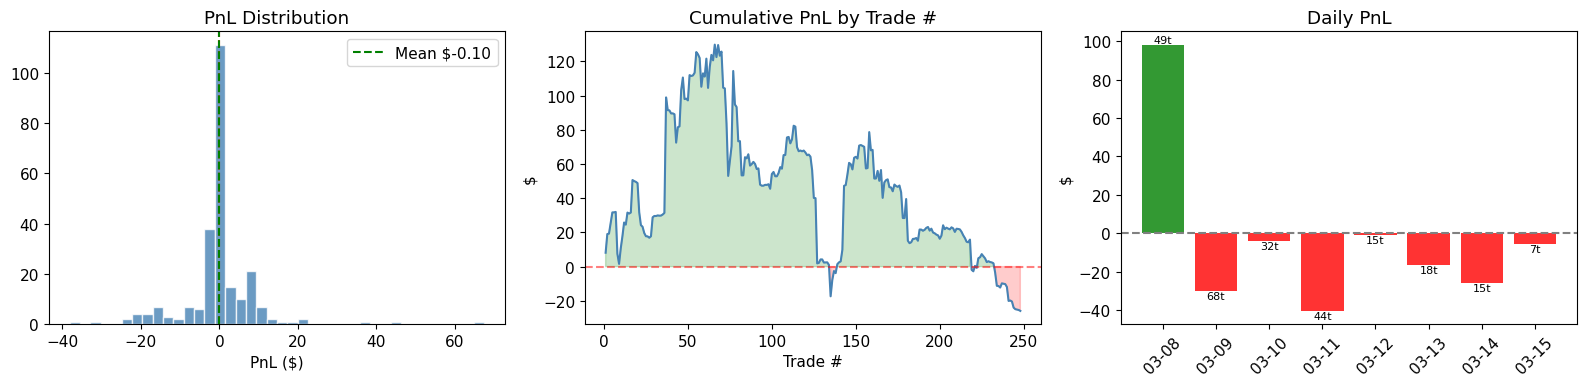

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(pnls, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].axvline(x=np.mean(pnls), color='green', linestyle='--', label=f'Mean ${np.mean(pnls):+.2f}')
axes[0].set_title('PnL Distribution')
axes[0].set_xlabel('PnL ($)')
axes[0].legend()

cum_pnl = np.cumsum(pnls)
axes[1].plot(range(1, len(cum_pnl)+1), cum_pnl, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].fill_between(range(1, len(cum_pnl)+1), cum_pnl, 0,
                     where=cum_pnl >= 0, color='green', alpha=0.2)
axes[1].fill_between(range(1, len(cum_pnl)+1), cum_pnl, 0,
                     where=cum_pnl < 0, color='red', alpha=0.2)
axes[1].set_title('Cumulative PnL by Trade #')
axes[1].set_xlabel('Trade #')
axes[1].set_ylabel('$')

if 'exit_date' in main_trades.columns:
    daily = main_trades.groupby('exit_date')['pnl'].agg(['sum', 'count'])
    colors_daily = ['green' if x >= 0 else 'red' for x in daily['sum']]
    axes[2].bar(range(len(daily)), daily['sum'], color=colors_daily, alpha=0.8)
    axes[2].set_xticks(range(len(daily)))
    axes[2].set_xticklabels([str(d)[-5:] for d in daily.index], rotation=45)
    axes[2].axhline(y=0, color='gray', linestyle='--')
    axes[2].set_title('Daily PnL')
    axes[2].set_ylabel('$')
    for i, (s, c) in enumerate(zip(daily['sum'], daily['count'])):
        axes[2].annotate(f'{int(c)}t', (i, s), ha='center',
                        va='bottom' if s >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

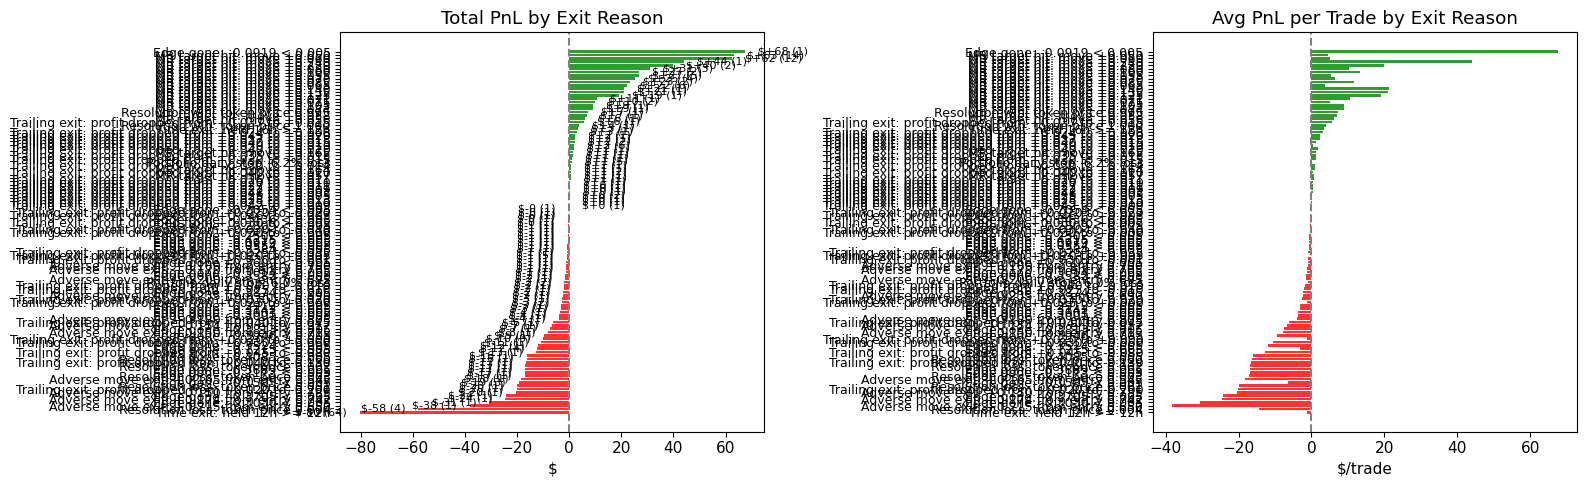


Детали:
  Time exit: held 12h >= 12h    :  64 trades, $  -80.31 total, $ -1.25/trade, WR 27%
  Resolution loss: token price 0.004:   4 trades, $  -57.79 total, $-14.45/trade, WR 0%
  Adverse move exit: +0.215 from entry 0.650:   1 trades, $  -38.15 total, $-38.15/trade, WR 0%
  Edge gone: -0.3030 < 0.005    :   1 trades, $  -30.62 total, $-30.62/trade, WR 0%
  Adverse move exit: +0.174 from entry 0.742:   1 trades, $  -24.47 total, $-24.47/trade, WR 0%
  Edge gone: -0.3705 < 0.005    :   1 trades, $  -24.36 total, $-24.36/trade, WR 0%
  Adverse move exit: +0.150 from entry 0.785:   1 trades, $  -20.50 total, $-20.50/trade, WR 0%
  Trailing exit: profit dropped from +0.020 to -0.200:   1 trades, $  -20.02 total, $-20.02/trade, WR 0%
  Resolution loss: token price 0.001:   1 trades, $  -20.01 total, $-20.01/trade, WR 0%
  Edge gone: -0.1585 < 0.005    :   3 trades, $  -19.25 total, $ -6.42/trade, WR 0%
  Adverse move exit: +0.165 from entry 0.545:   1 trades, $  -18.35 total, $-18.35/tr

In [7]:
reason_col = 'exit_reason' if 'exit_reason' in main_trades.columns else 'reason'
if reason_col in main_trades.columns:
    by_reason = main_trades.groupby(reason_col)['pnl'].agg(['sum', 'count', 'mean'])
    by_reason = by_reason.sort_values('sum')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    colors_r = ['green' if x >= 0 else 'red' for x in by_reason['sum']]
    bars = axes[0].barh(range(len(by_reason)), by_reason['sum'], color=colors_r, alpha=0.8)
    axes[0].set_yticks(range(len(by_reason)))
    axes[0].set_yticklabels(by_reason.index, fontsize=9)
    axes[0].axvline(x=0, color='gray', linestyle='--')
    axes[0].set_title('Total PnL by Exit Reason')
    axes[0].set_xlabel('$')
    for i, (s, c) in enumerate(zip(by_reason['sum'], by_reason['count'])):
        axes[0].text(s + (5 if s >= 0 else -5), i, f'${s:+.0f} ({c})',
                    va='center', ha='left' if s >= 0 else 'right', fontsize=8)

    colors_a = ['green' if x >= 0 else 'red' for x in by_reason['mean']]
    axes[1].barh(range(len(by_reason)), by_reason['mean'], color=colors_a, alpha=0.8)
    axes[1].set_yticks(range(len(by_reason)))
    axes[1].set_yticklabels(by_reason.index, fontsize=9)
    axes[1].axvline(x=0, color='gray', linestyle='--')
    axes[1].set_title('Avg PnL per Trade by Exit Reason')
    axes[1].set_xlabel('$/trade')

    plt.tight_layout()
    plt.show()

    print('\nДетали:')
    for idx, row in by_reason.iterrows():
        wr = (main_trades[main_trades[reason_col] == idx]['pnl'] > 0).mean() * 100
        print(f'  {idx:30s}: {int(row["count"]):3d} trades, '
              f'${row["sum"]:+8.2f} total, ${row["mean"]:+6.2f}/trade, WR {wr:.0f}%')

In [8]:
backtest = {
    'Period': 'Phase 5 (backtest)',
    'Trades': 688,
    'WR %': 73,
    'Avg PnL/trade $': 8.61,
    'Total PnL $': 5924,
    'Profit Factor': 2.22,
    'Flat-bet p-value': 0.003,
    'Avg Hold (hours)': 158,
    'Exit': 'Resolution only',
    'Model': 'HTR v1 (AUC=0.959)',
}

paper = {
    'Period': 'Phase 6 (paper)',
    'Trades': len(main_trades),
    'WR %': round((main_trades['pnl'] > 0).mean() * 100, 1),
    'Avg PnL/trade $': round(main_trades['pnl'].mean(), 2),
    'Total PnL $': round(main_trades['pnl'].sum(), 2),
    'Profit Factor': round(
        abs(main_trades.loc[main_trades['pnl'] > 0, 'pnl'].sum() /
            main_trades.loc[main_trades['pnl'] <= 0, 'pnl'].sum()), 2
    ) if (main_trades['pnl'] <= 0).any() else 'inf',
    'Avg Hold (hours)': round(main_trades['hold_hours'].mean(), 1) if 'hold_hours' in main_trades.columns else '?',
    'Exit': 'Multiple (MR/trailing/time/edge/adverse)',
    'Model': 'HTR v1 (same)',
}

comparison = pd.DataFrame([backtest, paper]).set_index('Period').T
comparison

Period,Phase 5 (backtest),Phase 6 (paper)
Trades,688,248
WR %,73.0,46.8
Avg PnL/trade $,8.61,-0.1
Total PnL $,5924.0,-25.88
Profit Factor,2.22,0.96
Flat-bet p-value,0.003,NaN
Avg Hold (hours),158.0,4.9
Exit,Resolution only,Multiple (MR/trailing/time/edge/adverse)
Model,HTR v1 (AUC=0.959),HTR v1 (same)


In [9]:
from scipy import stats

def deflated_sr(sr_observed, n_trials, n_obs, skew=0, kurtosis=3):
    """López de Prado Deflated Sharpe Ratio.

    Tests H0: SR* ≤ E[max(SR)] where SR* is observed and
    E[max] is expected max SR from N random trials.
    """

    euler_mascheroni = 0.5772
    e_max_sr = np.sqrt(2 * np.log(n_trials)) - \
               (np.log(np.pi) + euler_mascheroni) / (2 * np.sqrt(2 * np.log(n_trials)))

    se_sr = np.sqrt((1 - skew * sr_observed + (kurtosis - 1) / 4 * sr_observed**2) / n_obs)

    z = (sr_observed - e_max_sr) / se_sr
    p_value = stats.norm.cdf(z)

    return {
        'SR_observed': sr_observed,
        'E_max_SR': e_max_sr,
        'SE_SR': se_sr,
        'z': z,
        'p_value': p_value,
        'significant': p_value > 0.95,
    }

paper_returns = main_trades['pnl'].values / START_CAPITAL
paper_sr = np.mean(paper_returns) / np.std(paper_returns) * np.sqrt(252 * 24)

n_trials = 100

result = deflated_sr(
    sr_observed=paper_sr,
    n_trials=n_trials,
    n_obs=len(paper_returns),
    skew=pd.Series(paper_returns).skew(),
    kurtosis=pd.Series(paper_returns).kurtosis() + 3,
)

print('=== Deflated Sharpe Ratio (López de Prado Ch.8) ===')
for k, v in result.items():
    if isinstance(v, float):
        print(f'  {k:15s}: {v:.4f}')
    else:
        print(f'  {k:15s}: {v}')

print(f'\nВывод: SR observed = {result["SR_observed"]:.3f}')
print(f'E[max SR from {n_trials} random trials] = {result["E_max_SR"]:.3f}')
if not result['significant']:
    print('→ Наблюдаемый SR НЕ превышает ожидаемый от случайных стратегий')
    print('→ Нельзя отвергнуть H0: модель не лучше random')
else:
    print('→ SR значимо выше случайного')

=== Deflated Sharpe Ratio (López de Prado Ch.8) ===
  SR_observed    : -0.8600
  E_max_SR       : 2.7512
  SE_SR          : 0.1444
  z              : -25.0078
  p_value        : 0.0000
  significant    : False

Вывод: SR observed = -0.860
E[max SR from 100 random trials] = 2.751
→ Наблюдаемый SR НЕ превышает ожидаемый от случайных стратегий
→ Нельзя отвергнуть H0: модель не лучше random


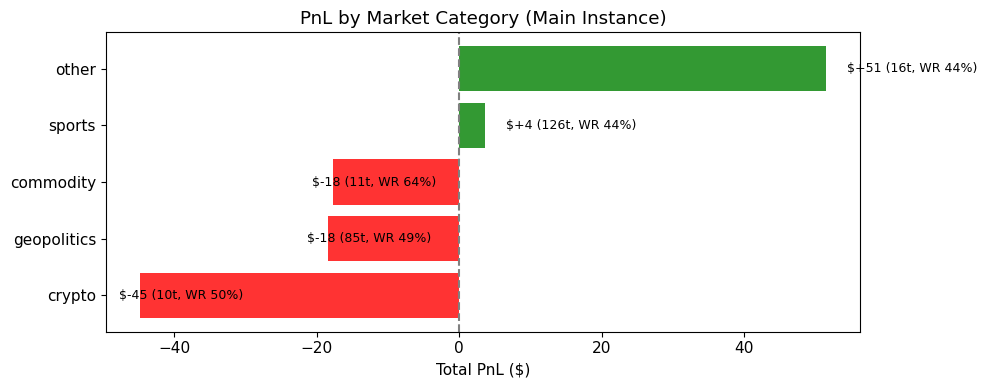

             trades  total_pnl  avg_pnl    wr
category                                     
crypto           10      -44.8     -4.5  50.0
geopolitics      85      -18.4     -0.2  49.4
commodity        11      -17.7     -1.6  63.6
sports          126        3.6      0.0  43.7
other            16       51.4      3.2  43.8


In [10]:
def classify_market(question):
    if not isinstance(question, str):
        return 'unknown'
    q = question.lower()
    sports_kw = ['vs.', 'spread:', 'o/u', 'nba', 'nfl', 'nhl', 'mlb', 'lol:',
                 'counter-strike', 'dota', 'esport', 'league of legends',
                 'playoffs', 'premier league', 'la liga', 'serie a',
                 'champions league', 'fc ', 'win the 202', 'world cup',
                 'stanley cup', 'super bowl']
    geo_kw = ['iran', 'russia', 'ukraine', 'war', 'ceasefire', 'regime',
              'forces', 'strike', 'military', 'invasion', 'offensive', 'lebanon']
    politics_kw = ['president', 'trump', 'democrat', 'republican', 'congress',
                   'governor', 'nomination', 'rubio', 'newsom', 'election']
    crypto_kw = ['bitcoin', 'btc', 'ethereum', 'eth', 'crypto']
    commodity_kw = ['crude oil', 'wti', 'brent', 'natural gas', 'gold price']

    for kw in crypto_kw:
        if kw in q: return 'crypto'
    for kw in commodity_kw:
        if kw in q: return 'commodity'
    for kw in sports_kw:
        if kw in q: return 'sports'
    for kw in geo_kw:
        if kw in q: return 'geopolitics'
    for kw in politics_kw:
        if kw in q: return 'politics'
    return 'other'

q_col = 'market_question' if 'market_question' in main_trades.columns else 'question'
if q_col in main_trades.columns:
    main_trades['category'] = main_trades[q_col].apply(classify_market)

    cat_stats = main_trades.groupby('category').agg(
        trades=('pnl', 'count'),
        total_pnl=('pnl', 'sum'),
        avg_pnl=('pnl', 'mean'),
        wr=('pnl', lambda x: (x > 0).mean() * 100),
    ).sort_values('total_pnl')

    fig, ax = plt.subplots(figsize=(10, 4))
    colors_cat = ['green' if x >= 0 else 'red' for x in cat_stats['total_pnl']]
    ax.barh(cat_stats.index, cat_stats['total_pnl'], color=colors_cat, alpha=0.8)
    ax.axvline(x=0, color='gray', linestyle='--')
    ax.set_title('PnL by Market Category (Main Instance)')
    ax.set_xlabel('Total PnL ($)')
    for i, (idx, row) in enumerate(cat_stats.iterrows()):
        ax.text(row['total_pnl'] + (3 if row['total_pnl'] >= 0 else -3), i,
                f'${row["total_pnl"]:+.0f} ({int(row["trades"])}t, WR {row["wr"]:.0f}%)',
                va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    print(cat_stats.round(1))

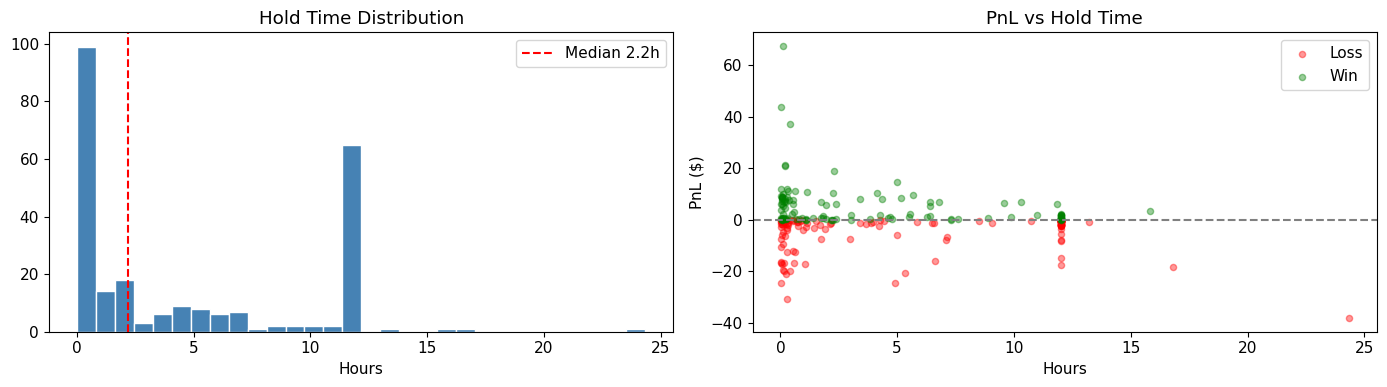

PnL by hold time bucket:
               n  total_pnl  avg_pnl     wr
hold_bucket                                
<1h          103      71.82     0.70  49.51
1-3h          29      16.51     0.57  62.07
3-6h          26       9.69     0.37  57.69
6-12h         22      10.36     0.47  63.64
12-24h        67     -96.11    -1.43  26.87
>24h           1     -38.15   -38.15   0.00


In [11]:
if 'hold_hours' in main_trades.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(main_trades['hold_hours'], bins=30, color='steelblue', edgecolor='white')
    axes[0].axvline(x=main_trades['hold_hours'].median(), color='red', linestyle='--',
                   label=f'Median {main_trades["hold_hours"].median():.1f}h')
    axes[0].set_title('Hold Time Distribution')
    axes[0].set_xlabel('Hours')
    axes[0].legend()

    wins = main_trades[main_trades['pnl'] > 0]
    losses = main_trades[main_trades['pnl'] <= 0]
    axes[1].scatter(losses['hold_hours'], losses['pnl'], c='red', alpha=0.4, s=20, label='Loss')
    axes[1].scatter(wins['hold_hours'], wins['pnl'], c='green', alpha=0.4, s=20, label='Win')
    axes[1].axhline(y=0, color='gray', linestyle='--')
    axes[1].set_title('PnL vs Hold Time')
    axes[1].set_xlabel('Hours')
    axes[1].set_ylabel('PnL ($)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    bins = [0, 1, 3, 6, 12, 24, 999]
    labels = ['<1h', '1-3h', '3-6h', '6-12h', '12-24h', '>24h']
    main_trades['hold_bucket'] = pd.cut(main_trades['hold_hours'], bins=bins, labels=labels)
    bucket_stats = main_trades.groupby('hold_bucket', observed=False).agg(
        n=('pnl', 'count'),
        total_pnl=('pnl', 'sum'),
        avg_pnl=('pnl', 'mean'),
        wr=('pnl', lambda x: (x > 0).mean() * 100 if len(x) > 0 else 0),
    )
    print('PnL by hold time bucket:')
    print(bucket_stats.round(2))

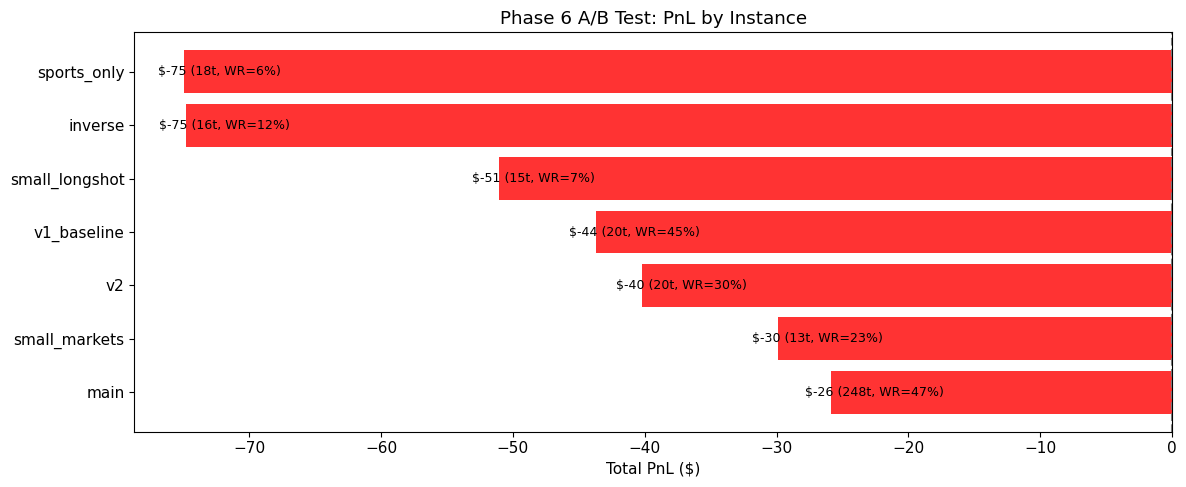


A/B Results:
      Instance                                                 Strategy  Trades        PnL  PnL/trade        WR Status
          main                                          HTR + all exits     248 -25.877649  -0.104345 46.774194   LOSS
 small_markets                         HTR on small markets (liq<$100K)      13 -29.872425  -2.297879 23.076923   LOSS
            v2 HTR + 5 fixes (penny, cooldown, adverse, time, trailing)      20 -40.171928  -2.008596 30.000000   LOSS
   v1_baseline                               HTR baseline (fresh start)      20 -43.731174  -2.186559 45.000000   LOSS
small_longshot                        HTR longshots (p<0.45, liq<$100K)      15 -51.069232  -3.404615  6.666667   LOSS
       inverse                                    Inverted HTR (sanity)      16 -74.805824  -4.675364 12.500000   LOSS
   sports_only                                          HTR sports only      18 -74.956236  -4.164235  5.555556   LOSS


In [12]:
ab_results = []
for name, data in instances.items():
    t = data['trades']
    if len(t) == 0:
        continue
    pnl = t['pnl'].sum()
    ab_results.append({
        'Instance': name,
        'Strategy': {
            'main': 'HTR + all exits',
            'v1_baseline': 'HTR baseline (fresh start)',
            'v2': 'HTR + 5 fixes (penny, cooldown, adverse, time, trailing)',
            'small_markets': 'HTR on small markets (liq<$100K)',
            'small_longshot': 'HTR longshots (p<0.45, liq<$100K)',
            'sports_only': 'HTR sports only',
            'inverse': 'Inverted HTR (sanity)',
        }.get(name, '?'),
        'Trades': len(t),
        'PnL': pnl,
        'PnL/trade': pnl / len(t),
        'WR': (t['pnl'] > 0).mean() * 100,
        'Status': 'LOSS' if pnl < 0 else 'PROFIT',
    })

ab_df = pd.DataFrame(ab_results).sort_values('PnL', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors_ab = ['green' if x >= 0 else 'red' for x in ab_df['PnL']]
bars = ax.barh(ab_df['Instance'], ab_df['PnL'], color=colors_ab, alpha=0.8)
ax.axvline(x=0, color='gray', linestyle='--')
ax.set_title('Phase 6 A/B Test: PnL by Instance')
ax.set_xlabel('Total PnL ($)')
for i, (_, row) in enumerate(ab_df.iterrows()):
    ax.text(row['PnL'] + (2 if row['PnL'] >= 0 else -2), i,
            f'${row["PnL"]:+.0f} ({int(row["Trades"])}t, WR={row["WR"]:.0f}%)',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nA/B Results:')
print(ab_df[['Instance', 'Strategy', 'Trades', 'PnL', 'PnL/trade', 'WR', 'Status']].to_string(index=False))

In [13]:
mr_trades = main_trades[main_trades[reason_col].str.contains('MR target', na=False)] if reason_col in main_trades.columns else pd.DataFrame()
non_mr = main_trades[~main_trades[reason_col].str.contains('MR target', na=False)] if reason_col in main_trades.columns else pd.DataFrame()

if len(mr_trades) > 0:
    print(f'MR target trades: {len(mr_trades)}')
    print(f'  Total PnL: ${mr_trades["pnl"].sum():+.2f}')
    print(f'  Avg PnL: ${mr_trades["pnl"].mean():+.2f}')
    print(f'  WR: {(mr_trades["pnl"] > 0).mean()*100:.0f}%')
    print(f'  Avg hold: {mr_trades["hold_hours"].mean():.1f}h')
    print()
    print(f'Non-MR trades (closed early): {len(non_mr)}')
    print(f'  Total PnL: ${non_mr["pnl"].sum():+.2f}')
    print(f'  Avg PnL: ${non_mr["pnl"].mean():+.2f}')
    print(f'  WR: {(non_mr["pnl"] > 0).mean()*100:.0f}%')
    print(f'  Avg hold: {non_mr["hold_hours"].mean():.1f}h')
    print()
    print('=== Counterfactual: если бы ВСЕ trades = MR target ===')
    print(f'  Expected PnL: 248 × ${mr_trades["pnl"].mean():+.2f} = ${248 * mr_trades["pnl"].mean():+.0f}')
    print(f'  vs actual: ${main_trades["pnl"].sum():+.2f}')
    print(f'  Lost edge from early exits: ${248 * mr_trades["pnl"].mean() - main_trades["pnl"].sum():+.0f}')

MR target trades: 64
  Total PnL: $+480.51
  Avg PnL: $+7.51
  WR: 100%
  Avg hold: 1.9h

Non-MR trades (closed early): 184
  Total PnL: $-506.39
  Avg PnL: $-2.75
  WR: 28%
  Avg hold: 5.9h

=== Counterfactual: если бы ВСЕ trades = MR target ===
  Expected PnL: 248 × $+7.51 = $+1862
  vs actual: $-25.88
  Lost edge from early exits: $+1888


In [14]:
print('=' * 70)
print('PHASE 6 VERDICT: NO GO FOR PHASE 7')
print('=' * 70)
print()
print('Key findings:')
print('  1. ALL 7 configurations are UNPROFITABLE')
print(f'  2. Main: {len(main_trades)} trades, PnL ${main_trades["pnl"].sum():+.2f}, WR {(main_trades["pnl"]>0).mean()*100:.0f}%')
print(f'  3. MR target is ONLY profitable exit (+$480, 64 trades)')
print(f'  4. Early exits DESTROY edge (-$510 across 184 trades)')
print(f'  5. Backtest vs paper: $8.61/trade → $-0.10/trade')
print(f'  6. Sports WR=6%, Longshots WR=7% — no edge')
print()
print('Root cause: EXIT MECHANISM MISMATCH')
print('  Backtest: hold-to-resolution (median 158h)')
print(f'  Paper: median hold {main_trades["hold_hours"].median():.1f}h — 72x shorter')
print()
print('Next: Phase 6 v2 — pure HTR (no early exits) + meta-labeling filter')

PHASE 6 VERDICT: NO GO FOR PHASE 7

Key findings:
  1. ALL 7 configurations are UNPROFITABLE
  2. Main: 248 trades, PnL $-25.88, WR 47%
  3. MR target is ONLY profitable exit (+$480, 64 trades)
  4. Early exits DESTROY edge (-$510 across 184 trades)
  5. Backtest vs paper: $8.61/trade → $-0.10/trade
  6. Sports WR=6%, Longshots WR=7% — no edge

Root cause: EXIT MECHANISM MISMATCH
  Backtest: hold-to-resolution (median 158h)
  Paper: median hold 2.2h — 72x shorter

Next: Phase 6 v2 — pure HTR (no early exits) + meta-labeling filter
